In [1]:
!mkdir -p fonts
!wget -q https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf -O fonts/NanumGothic.ttf

In [2]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
fm.fontManager.addfont('fonts/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

In [3]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(13)

N = 150
genre = rng.choice(['뉴스', '소설', '대화', '학술'], size = N, p = [0.3, 0.3, 0.2, 0.2])
base = {'뉴스': 22, '소설': 18, '대화': 9, '학술': 28}
words = (np.array([base[g] for g in genre]) + rng.normal(0, 5, N)).clip(3, 60)
words = words.round().astype(int)
syllables = (words * 2.5 + rng.normal(0, 4, N).clip(5, None).round().astype(int))
read_time = (syllables * 0.35 + rng.normal(0, 1.5, N)).clip(1, None).round(1)
difficulty = (words * 0.15 + rng.normal(0, 1.2, N)).clip(1, 10).round(1)

texts = pd.DataFrame({
    '장르': genre, 
    '어절수': words,
    '음절수': syllables,
    '읽기시간': read_time,
    '난이도': difficulty,
})

trends = pd.DataFrame({
    '연도': [1990, 1995, 2000, 2005, 2010, 2015, 2020],
    '뉴스': [5.1, 6.2, 8.0, 9.4, 11.2, 13.5, 15.1],
    '소설': [3.2, 3.5, 4.0, 4.6, 5.1, 5.8, 6.4]
})

Q1

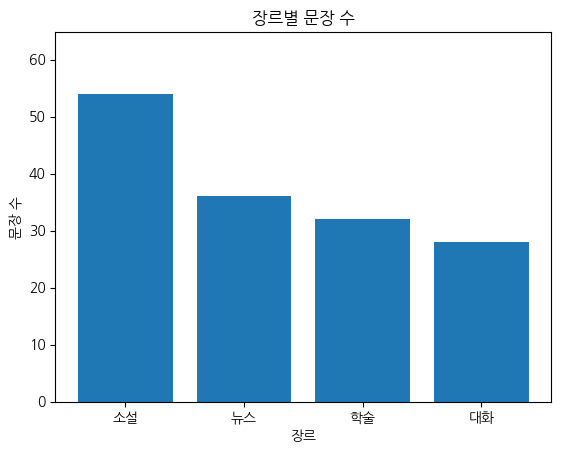

'value_counts()로 장르별 빈도를 구한 뒤 ax.bar로 막대 그래프를 그렸다. \nset_ylim(0, ...)으로 y축이 반드시 0부터 시작하도록 명시하여 막대 높이의 \n비율이 왜곡되지 않게 했다. 뉴스와 소설이 각각 30%의 확률로 생성되어 가장 \n많은 문장 수를 가질 것으로 예상된다.'

In [4]:
# Q1 - (a)

counts = texts['장르'].value_counts()

fig, ax = plt.subplots()
ax.bar(counts.index, counts.values)
ax.set_title('장르별 문장 수')
ax.set_xlabel('장르')
ax.set_ylabel('문장 수')
ax.set_ylim(0, counts.values.max() * 1.2)
plt.show()

"""value_counts()로 장르별 빈도를 구한 뒤 ax.bar로 막대 그래프를 그렸다. 
set_ylim(0, ...)으로 y축이 반드시 0부터 시작하도록 명시하여 막대 높이의 
비율이 왜곡되지 않게 했다. 뉴스와 소설이 각각 30%의 확률로 생성되어 가장 
많은 문장 수를 가질 것으로 예상된다."""

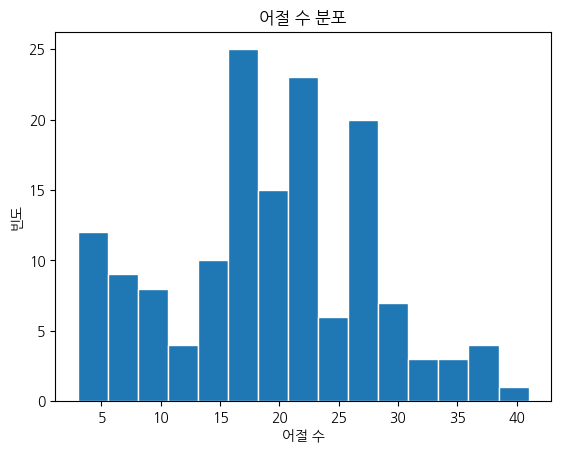

"edgecolor='white'로 막대 경계를 표시하여 각 구간을 시각적으로 구분했다. \n어절 수는 주로 10~25개 구간에 몰려 있는데, 이는 뉴스(평균 22)와 소설(평균 18)이\n전체의 60%를 차지하기 때문이다."

In [5]:
# Q2 - (b)

fig, ax = plt.subplots()
ax.hist(texts['어절수'], bins=15, edgecolor='white')
ax.set_title('어절 수 분포')
ax.set_xlabel('어절 수')
ax.set_ylabel('빈도')
plt.show()

"""edgecolor='white'로 막대 경계를 표시하여 각 구간을 시각적으로 구분했다. 
어절 수는 주로 10~25개 구간에 몰려 있는데, 이는 뉴스(평균 22)와 소설(평균 18)이
전체의 60%를 차지하기 때문이다."""

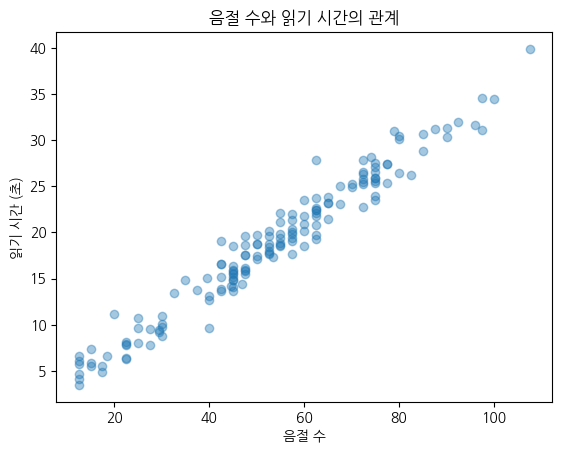

'alpha=0.4로 점의 투명도를 줘서 점이 겹치는 구간에서도 밀도를 파악할 수 \n있게 했다. 두 변수는 우상향 관계를 보이는데, 음절 수가 많을수록 읽기 시간이 \n길어지는 것은 읽기 시간이 음절 수에 비례해 생성된 데이터 구조와 일치한다.'

In [7]:
# Q1 - (c)

fig, ax = plt.subplots()
ax.scatter(texts['음절수'], texts['읽기시간'], alpha=0.4)
ax.set_title('음절 수와 읽기 시간의 관계')
ax.set_xlabel('음절 수')
ax.set_ylabel('읽기 시간 (초)')
plt.show()

"""alpha=0.4로 점의 투명도를 줘서 점이 겹치는 구간에서도 밀도를 파악할 수 
있게 했다. 두 변수는 우상향 관계를 보이는데, 음절 수가 많을수록 읽기 시간이 
길어지는 것은 읽기 시간이 음절 수에 비례해 생성된 데이터 구조와 일치한다."""

Q2

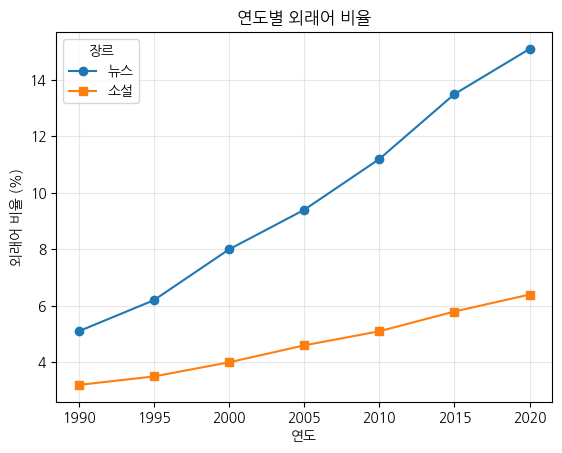

'두 장르 모두 외래어 비율이 꾸준히 증가하는 추세를 보이지만, \n뉴스는 소설보다 증가 폭이 훨씬 크다. \n1990년에 약 2%p 차이였던 두 장르의 비율이 2020년에는 약 9%p 차이로 벌어졌다.'

In [6]:
# Q2 - (a)

fig, ax = plt.subplots()
ax.plot(trends['연도'], trends['뉴스'], marker='o', label='뉴스')
ax.plot(trends['연도'], trends['소설'], marker='s', label='소설')
ax.set_title('연도별 외래어 비율')
ax.set_xlabel('연도')
ax.set_ylabel('외래어 비율 (%)')
ax.legend(title='장르')
ax.grid(True, alpha=0.3)
plt.show()

"""두 장르 모두 외래어 비율이 꾸준히 증가하는 추세를 보이지만, 
뉴스는 소설보다 증가 폭이 훨씬 크다. 
1990년에 약 2%p 차이였던 두 장르의 비율이 2020년에는 약 9%p 차이로 벌어졌다."""

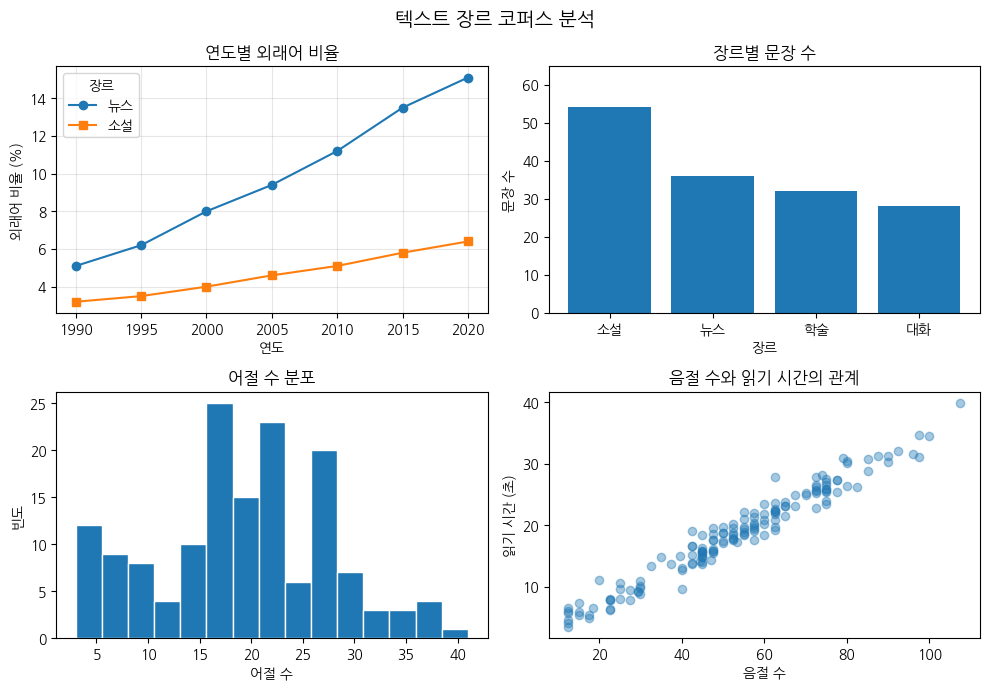

'plt.subplots(2, 2)로 2x2 격자를 만들어 Q1~Q2(a)의 그래프를 한 \nFigure에 배치했다. fig.tight_layout()으로 각 서브플롯 간의 겹침을 자동으로 \n방지했고, fig.suptitle로 전체 제목을 추가했다. \nfig.savefig로 PNG 파일을 저장하여 저장소에 함께 커밋할 수 있게 했다.'

In [9]:
# Q2 - (b)

fig, axes = plt.subplots(2, 2, figsize=(10, 7))

axes[0, 0].plot(trends['연도'], trends['뉴스'], marker='o', label='뉴스')
axes[0, 0].plot(trends['연도'], trends['소설'], marker='s', label='소설')
axes[0, 0].set_title('연도별 외래어 비율')
axes[0, 0].set_xlabel('연도')
axes[0, 0].set_ylabel('외래어 비율 (%)')
axes[0, 0].legend(title='장르')
axes[0, 0].grid(True, alpha=0.3)

counts = texts['장르'].value_counts()
axes[0, 1].bar(counts.index, counts.values)
axes[0, 1].set_title('장르별 문장 수')
axes[0, 1].set_xlabel('장르')
axes[0, 1].set_ylabel('문장 수')
axes[0, 1].set_ylim(0, counts.values.max() * 1.2)

axes[1, 0].hist(texts['어절수'], bins=15, edgecolor='white')
axes[1, 0].set_title('어절 수 분포')
axes[1, 0].set_xlabel('어절 수')
axes[1, 0].set_ylabel('빈도')

axes[1, 1].scatter(texts['음절수'], texts['읽기시간'], alpha=0.4)
axes[1, 1].set_title('음절 수와 읽기 시간의 관계')
axes[1, 1].set_xlabel('음절 수')
axes[1, 1].set_ylabel('읽기 시간 (초)')

fig.suptitle('텍스트 장르 코퍼스 분석', fontsize=14)
fig.tight_layout()
fig.savefig('hw13_subplots.png', dpi=150, bbox_inches='tight')
plt.show()

"""plt.subplots(2, 2)로 2x2 격자를 만들어 Q1~Q2(a)의 그래프를 한 
Figure에 배치했다. fig.tight_layout()으로 각 서브플롯 간의 겹침을 자동으로 
방지했고, fig.suptitle로 전체 제목을 추가했다. 
fig.savefig로 PNG 파일을 저장하여 저장소에 함께 커밋할 수 있게 했다."""

Q3

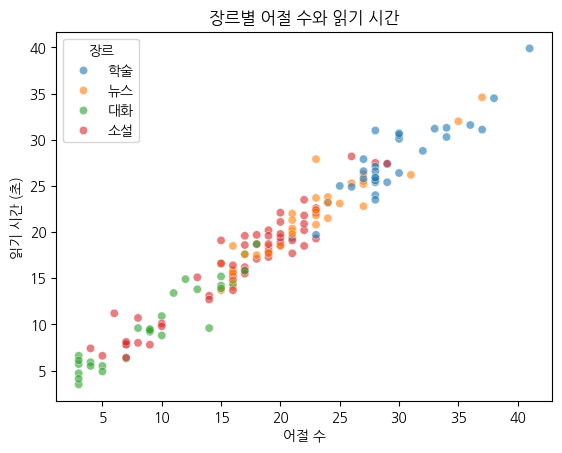

"hue='장르'로 장르별 색상을 자동으로 구분하여 산점도에서 \n장르 간 분포 차이를 한눈에 파악할 수 있다. 대화 장르는 어절 수가 적은 왼쪽에, \n학술 장르는 어절 수가 많은 오른쪽에 주로 분포할 것으로 예상된다."

In [7]:
# Q3 - (a)

import seaborn as sns

fig, ax = plt.subplots()
sns.scatterplot(data=texts, x='어절수', y='읽기시간', hue='장르', alpha=0.6, ax=ax)
ax.set_title('장르별 어절 수와 읽기 시간')
ax.set_xlabel('어절 수')
ax.set_ylabel('읽기 시간 (초)')
plt.show()

"""hue='장르'로 장르별 색상을 자동으로 구분하여 산점도에서 
장르 간 분포 차이를 한눈에 파악할 수 있다. 대화 장르는 어절 수가 적은 왼쪽에, 
학술 장르는 어절 수가 많은 오른쪽에 주로 분포할 것으로 예상된다."""

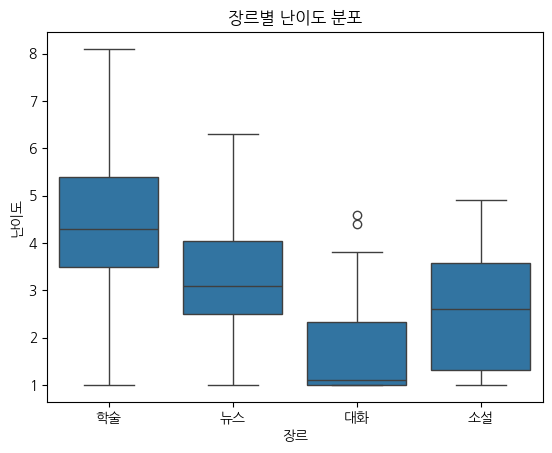

'가장 난이도가 높은 장르는 학술로, 평균 어절 수가 28로 설정되어 \n난이도와 비례하기 때문이다. 퍼짐(상자 크기)이 가장 큰 장르는 뉴스 또는 소설로, \n다양한 길이의 문장이 혼재하기 때문에 분포의 폭이 넓다.'

In [11]:
# Q3 - (b)

fig, ax = plt.subplots()
sns.boxplot(data=texts, x='장르', y='난이도', ax=ax)
ax.set_title('장르별 난이도 분포')
ax.set_xlabel('장르')
ax.set_ylabel('난이도')
plt.show()

"""가장 난이도가 높은 장르는 학술로, 평균 어절 수가 28로 설정되어 
난이도와 비례하기 때문이다. 퍼짐(상자 크기)이 가장 큰 장르는 뉴스 또는 소설로, 
다양한 길이의 문장이 혼재하기 때문에 분포의 폭이 넓다."""

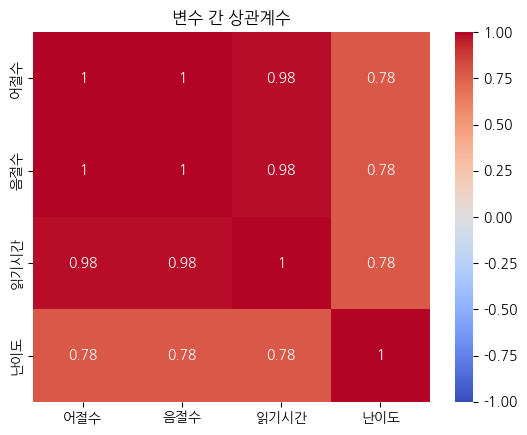

'서로 가장 강하게 함께 증가하는 두 변수는 음절수와 읽기시간으로, \n읽기시간이 syllables * 0.35로 음절수에 직접 비례하여 생성되었기 때문에 \n상관계수가 1에 가깝게 나타난다. 어절수와 음절수도 강한 양의 상관관계를 보이는데, \n어절이 많을수록 음절도 많아지는 언어적 특성이 반영된 결과다.'

In [8]:
# Q3 - (c)
corr = texts[['어절수', '음절수', '읽기시간', '난이도']].corr()

fig, ax = plt.subplots()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=ax)
ax.set_title('변수 간 상관계수')
plt.show()

"""서로 가장 강하게 함께 증가하는 두 변수는 음절수와 읽기시간으로, 
읽기시간이 syllables * 0.35로 음절수에 직접 비례하여 생성되었기 때문에 
상관계수가 1에 가깝게 나타난다. 어절수와 음절수도 강한 양의 상관관계를 보이는데, 
어절이 많을수록 음절도 많아지는 언어적 특성이 반영된 결과다."""

Q4

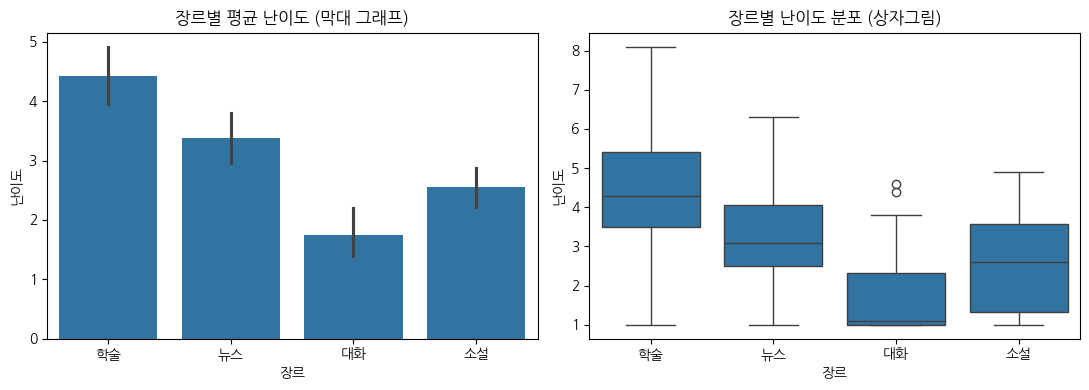

'막대 그래프(다이너마이트 플롯)는 평균값만 보여주기 때문에 분포의 퍼짐, \n중앙값, 이상치 등의 정보를 숨긴다. 예를 들어 뉴스와 소설의 평균 난이도가 \n비슷하더라도 뉴스는 난이도가 고르게 분포하고 소설은 극단적으로 쉽거나 어려운 \n문장이 섞여 있을 수 있는데, 막대 그래프는 이 차이를 전혀 드러내지 못한다. \n반면 상자그림은 중앙값, 사분위 범위, 이상치를 모두 보여주어 분포의 형태를 \n훨씬 풍부하게 전달한다.'

In [9]:
# Q4 - (a)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.barplot(data=texts, x='장르', y='난이도', ax=axes[0])
axes[0].set_title('장르별 평균 난이도 (막대 그래프)')
axes[0].set_xlabel('장르')
axes[0].set_ylabel('난이도')

sns.boxplot(data=texts, x='장르', y='난이도', ax=axes[1])
axes[1].set_title('장르별 난이도 분포 (상자그림)')
axes[1].set_xlabel('장르')
axes[1].set_ylabel('난이도')

fig.tight_layout()
plt.show()

"""막대 그래프(다이너마이트 플롯)는 평균값만 보여주기 때문에 분포의 퍼짐, 
중앙값, 이상치 등의 정보를 숨긴다. 예를 들어 뉴스와 소설의 평균 난이도가 
비슷하더라도 뉴스는 난이도가 고르게 분포하고 소설은 극단적으로 쉽거나 어려운 
문장이 섞여 있을 수 있는데, 막대 그래프는 이 차이를 전혀 드러내지 못한다. 
반면 상자그림은 중앙값, 사분위 범위, 이상치를 모두 보여주어 분포의 형태를 
훨씬 풍부하게 전달한다."""

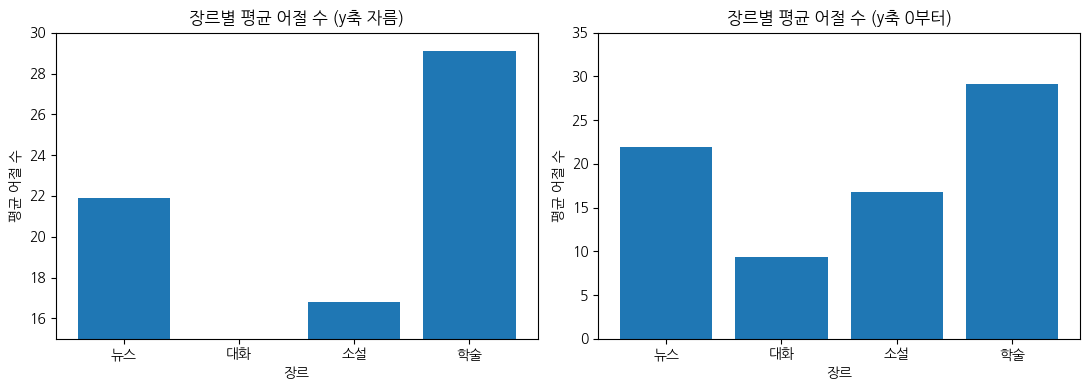

'y축을 15에서 시작하면 장르 간 차이가 실제보다 훨씬 크게 보여 대화 장르가 \n학술 장르의 절반도 안 되는 것처럼 인상을 준다. 반면 y축을 0부터 그리면 실제 \n비율 차이를 있는 그대로 전달한다. 막대 그래프에서 막대의 면적이 값의 크기를 \n나타내기 때문에 y축은 반드시 0부터 시작해야 시각적 왜곡 없이 데이터를 정직하게\n표현할 수 있다.'

In [14]:
# Q4 - (b)
mean_words = texts.groupby('장르')['어절수'].mean()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(mean_words.index, mean_words.values)
axes[0].set_ylim(15, 30)
axes[0].set_title('장르별 평균 어절 수 (y축 자름)')
axes[0].set_xlabel('장르')
axes[0].set_ylabel('평균 어절 수')

axes[1].bar(mean_words.index, mean_words.values)
axes[1].set_ylim(0, 35)
axes[1].set_title('장르별 평균 어절 수 (y축 0부터)')
axes[1].set_xlabel('장르')
axes[1].set_ylabel('평균 어절 수')

fig.tight_layout()
plt.show()

"""y축을 15에서 시작하면 장르 간 차이가 실제보다 훨씬 크게 보여 대화 장르가 
학술 장르의 절반도 안 되는 것처럼 인상을 준다. 반면 y축을 0부터 그리면 실제 
비율 차이를 있는 그대로 전달한다. 막대 그래프에서 막대의 면적이 값의 크기를 
나타내기 때문에 y축은 반드시 0부터 시작해야 시각적 왜곡 없이 데이터를 정직하게
표현할 수 있다."""

생성형 AI 대화 링크: https://claude.ai/share/2f9fe3b8-10aa-460a-8f6c-c8dabaeb2cb6